 Now, initially start with a base line XGboost model and then we will find the optimized parameters for the model

In [3]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np

In [6]:
from xgboost import XGBRegressor 

from sklearn.metrics import (
          r2_score,
          mean_absolute_error
)

In [7]:
model = XGBRegressor(
    random_state=42
)

In [8]:
x_train = pd.read_csv("x_train.csv")
y_train = pd.read_csv("y_train.csv")
x_test = pd.read_csv("x_test.csv")
y_test = pd.read_csv("y_test.csv")


In [9]:
model.fit(
     x_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
y_pred = model.predict(x_test)

In [11]:
y_pred[:10]


array([0.2996071 , 0.39244595, 0.46028447, 0.5052039 , 0.5498252 ,
       0.78273976, 0.3611951 , 0.6347436 , 0.7953974 , 0.86791605],
      dtype=float32)

In [12]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² =", r2)

R² = 0.6360927820205688


In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE =", mae)

MAE = 0.1642647385597229


In [14]:
# Also take a look at the training data
train_pred = model.predict(x_train)

In [15]:
train_pred[:9]

array([0.27831805, 0.41911757, 0.5589168 , 0.6915414 , 0.80301476,
       0.89956665, 0.9835741 , 1.1197482 , 0.17583762], dtype=float32)

In [16]:
r2 = r2_score(
    y_train,
    train_pred
)

print("R² =", r2)

R² = 0.9949943423271179


In [17]:
train_mae = mean_absolute_error(
    y_train,
    train_pred
)

print("MAE =", train_mae)

MAE = 0.007251099217683077


* Train R² = 0.9949943423271179
* Test R² = 0.6360927820205688
  
So, there exists overfitting (Model memorized training data).

In [18]:
import pickle

with open("xgb_baseline.pkl","wb") as f:
    pickle.dump(model,f)

TO overcome the overfitting and to find optimized hyperparameters we will use RandomizedSearchCV

In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [20]:
# This is the search Space
param_dist = {
    "max_depth": [2,3,4,5,6],

    "learning_rate": [0.01,0.02,0.05,0.1],

    "n_estimators": [100,200,500],

    "subsample": [0.6,0.8,1.0],

    "colsample_bytree": [0.6,0.8,1.0],

    "reg_alpha": [0,1,3,6,10],

    "reg_lambda": [1,3,5,10],

    "min_child_weight": [1,3,5]
}

In [21]:
search = RandomizedSearchCV(
    estimator=model,

    param_distributions=param_dist,

    n_iter=100,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1,

    verbose=1
)

In [22]:
search.fit(x_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [23]:
print(search.best_params_)

{'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 3, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


In [24]:
print(search.best_score_)

0.7571158766746521


In [25]:
best_model = search.best_estimator_

In [26]:
Y_pred = best_model.predict(x_test)

In [27]:
best_r2 = r2_score(
    y_test,
    Y_pred
)

In [28]:
print(best_r2)

0.6923245191574097


In [29]:
train_pred = best_model.predict(x_train)


Train_all_r2 =   r2_score(
        y_train,
        train_pred
    )

print("Train_R2: ", Train_all_r2)

Train_R2:  0.9436091780662537


* As of now we are using all the using all the features, but we need to remove the unrelated features and which can be done through **Feature Selection**.

In [30]:
feat_imp = pd.DataFrame({
    "feature":x_train.columns,
    "importance":best_model.feature_importances_
})

feat_imp = feat_imp.sort_values(
    "importance",
    ascending=False
)

In [31]:
feat_imp.head(20)

,feature,importance
35,MagpieData avg_dev Row,0.097822
41,MagpieData avg_dev CovalentRadius,0.086151
0,Temperature,0.084878
65,MagpieData avg_dev NdValence,0.068590
103,MagpieData minimum NUnfilled,0.063791
113,MagpieData avg_dev GSvolume_pa,0.049694
112,MagpieData mean GSvolume_pa,0.045507
2,MagpieData maximum Number,0.044082
20,MagpieData maximum MeltingT,0.033121
86,MagpieData maximum NpUnfilled,0.019075


In [32]:
# try top 25 features 
top25 = feat_imp.head(25)["feature"]

x_train_25 = x_train[top25]
x_test_25 = x_test[top25]

In [33]:
model_25 = XGBRegressor(
    **search.best_params_,
    random_state=42
)

model_25.fit(
    x_train_25,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
y_pred_25 = model_25.predict(x_test_25)

In [35]:
y_pred_25[:8]

array([0.22498387, 0.3031641 , 0.436192  , 0.56707186, 0.72641355,
       0.8720944 , 0.42186394, 0.52588147], dtype=float32)

In [36]:
r2_25 = r2_score(
    y_test,
    y_pred_25
)

print("R² =", r2_25)

R² = 0.7022716999053955


In [37]:
# Try top 50 features
top50 = feat_imp.head(50)["feature"]

x_train_50 = x_train[top50]
x_test_50 = x_test[top50]

In [38]:
model_50 = XGBRegressor(
    **search.best_params_,
    random_state=42
)

model_50.fit(
    x_train_50,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
y_pred_50 = model_50.predict(x_test_50)

In [40]:
r2_50 = r2_score(
    y_test,
    y_pred_50
)
print("R² =", r2_50)

R² = 0.7147465348243713


In [41]:
# Try top 75 features
top75 = feat_imp.head(75)["feature"]

x_train_75 = x_train[top75]
x_test_75 = x_test[top75]

In [42]:
model_75 = XGBRegressor(
    **search.best_params_,
    random_state=42
)

model_75.fit(
    x_train_75,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
y_pred_75 = model_75.predict(x_test_75)

In [44]:
r2_75 = r2_score(
    y_test,
    y_pred_75
)
print("R² =", r2_75)

R² = 0.7080469131469727


In [45]:
# comparing results
results = pd.DataFrame({
    "Features":["All","Top25","Top50","Top75"],
    "Test_R2":[
        best_r2,
        r2_25,
        r2_50,
        r2_75
    ]
})

print(results)

  Features   Test_R2
0      All  0.692325
1    Top25  0.702272
2    Top50  0.714747
3    Top75  0.708047


 SO, with top 50 features it gives the best r2 value.

In [46]:
# Now look at the train data for TOP 50 features

train_pred_50 = model_50.predict(x_train_50)
r2_train_50 = r2_score(
    y_train,
    train_pred_50
)
print("Train R² =", r2_train_50)

Train R² = 0.9416772723197937


In [47]:
import pickle

with open("top50_features.pkl", "wb") as f:
    pickle.dump(top50, f)

In [48]:
# Comparing the r2
Compare_50 = pd.DataFrame({
    "Model":["All_features","Top50"],
    "Test_R2":[
        best_r2,
        r2_50,
    ],
    "Train_R2":[
        Train_all_r2,
        r2_train_50
    ]
})
print(Compare_50)

          Model   Test_R2  Train_R2
0  All_features  0.692325  0.943609
1         Top50  0.714747  0.941677


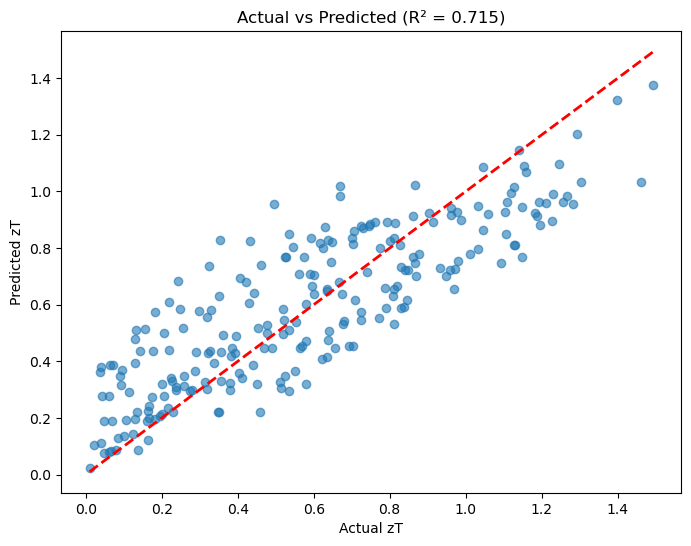

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_50)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual zT")
plt.ylabel("Predicted zT")
plt.title(f"Actual vs Predicted (R² = {r2:.3f})")

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

So our current best model is the Top 50 feature model.

 Now to check the stability of the model we will use **5-Fold Cross Validation**

In [49]:
df_features = pd.read_csv("Magpie_Features.csv")


In [50]:
df_features

,Temperature,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,ZT
0,350,11.0,82.0,71.0,57.519608,16.800269,52.0,2.0,90.0,88.0,...,0.000046,0.000078,0.0,152.0,229.0,77.0,188.117647,35.409458,152.0,0.276253
1,400,11.0,82.0,71.0,57.519608,16.800269,52.0,2.0,90.0,88.0,...,0.000046,0.000078,0.0,152.0,229.0,77.0,188.117647,35.409458,152.0,0.420050
2,450,11.0,82.0,71.0,57.519608,16.800269,52.0,2.0,90.0,88.0,...,0.000046,0.000078,0.0,152.0,229.0,77.0,188.117647,35.409458,152.0,0.563897
3,500,11.0,82.0,71.0,57.519608,16.800269,52.0,2.0,90.0,88.0,...,0.000046,0.000078,0.0,152.0,229.0,77.0,188.117647,35.409458,152.0,0.689989
4,550,11.0,82.0,71.0,57.519608,16.800269,52.0,2.0,90.0,88.0,...,0.000046,0.000078,0.0,152.0,229.0,77.0,188.117647,35.409458,152.0,0.799702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,550,11.0,82.0,71.0,65.957500,15.320588,52.0,2.0,90.0,88.0,...,0.000000,0.000000,0.0,152.0,229.0,77.0,188.065000,36.065000,152.0,0.982589
1176,600,11.0,82.0,71.0,65.957500,15.320588,52.0,2.0,90.0,88.0,...,0.000000,0.000000,0.0,152.0,229.0,77.0,188.065000,36.065000,152.0,1.228149
1177,650,11.0,82.0,71.0,65.957500,15.320588,52.0,2.0,90.0,88.0,...,0.000000,0.000000,0.0,152.0,229.0,77.0,188.065000,36.065000,152.0,1.438621
1178,700,11.0,82.0,71.0,65.957500,15.320588,52.0,2.0,90.0,88.0,...,0.000000,0.000000,0.0,152.0,229.0,77.0,188.065000,36.065000,152.0,1.587491


In [51]:
x = df_features.drop(columns=["ZT"])

y = df_features["ZT"]


In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_50,
    x[top50],
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold Scores:")
print(scores)

print("\nMean R²:")
print(scores.mean())

print("\nStd:")
print(scores.std())

Fold Scores:
[0.63226737 0.81162915 0.79229252 0.79443    0.73067607]

Mean R²:
0.7522590203508657

Std:
0.06598440009401871


Interpretation:

* Mean R² ≈ 0.75 → good predictive performance for a data set of only 1180 samples.
* Std ≈ 0.066 → reasonably stable.
* One fold (0.632) is noticeably harder than the others, which suggests some compounds are more difficult to predict than others.

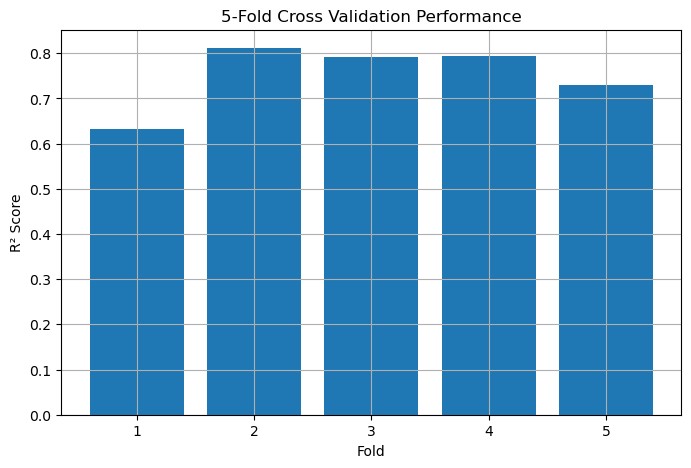

In [67]:
import matplotlib.pyplot as plt

cv_scores = [0.63226737, 0.81162915, 0.79229252, 0.79443, 0.73067607]
folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(8,5))
plt.bar(folds, cv_scores)

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-Fold Cross Validation Performance")
plt.grid(True)

# Save figure
plt.savefig(
    "cross_validation_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP Analysis


In [53]:
# Now we will move forward to Shap analysis 
import shap
import matplotlib.pyplot as plt

In [54]:
explainer = shap.TreeExplainer(model_50)

In [55]:
shap_values = explainer.shap_values(x_test_50)

In [56]:
print(shap_values.shape)
print(x_test_50.shape)

(232, 50)
(232, 50)


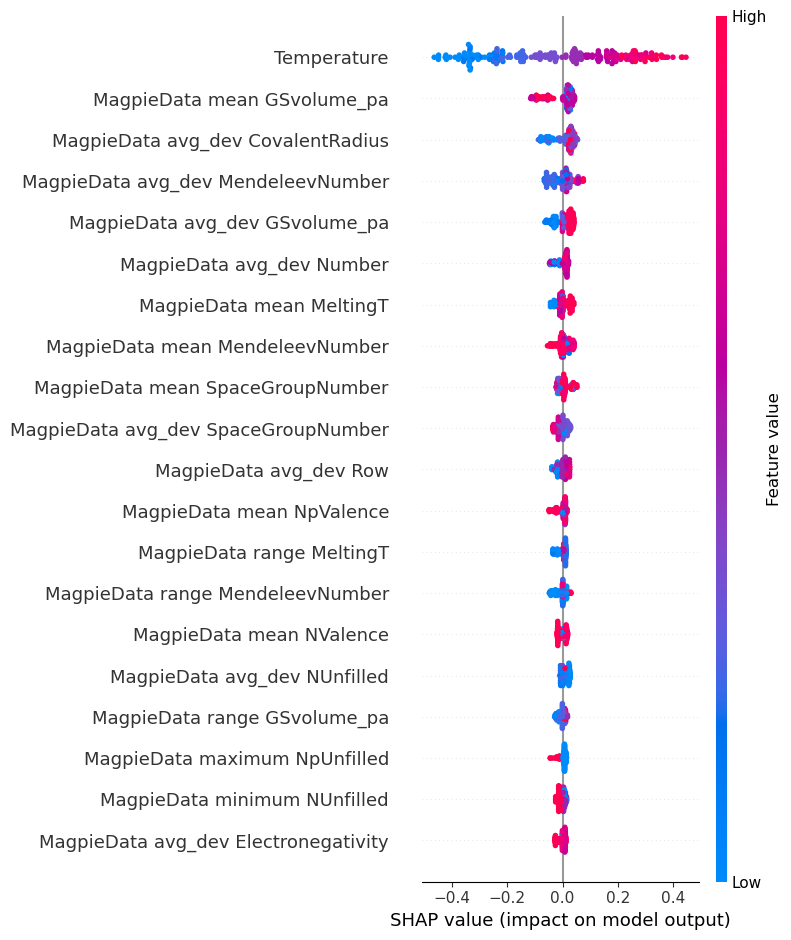

In [57]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    x_test_50,
    show=False
)

plt.tight_layout()

plt.savefig(
    "SHAP_Summary.png",
    dpi=300
)

plt.show()

In [58]:
# importance table for shap values 
shap_importance = pd.DataFrame({
    "Feature": x_test_50.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Importance",
    ascending=False
)

print(shap_importance.head(20))

                                 Feature  Importance
2                            Temperature    0.210463
6            MagpieData mean GSvolume_pa    0.033905
1      MagpieData avg_dev CovalentRadius    0.033621
11    MagpieData avg_dev MendeleevNumber    0.026665
5         MagpieData avg_dev GSvolume_pa    0.026160
12             MagpieData avg_dev Number    0.015770
16              MagpieData mean MeltingT    0.015300
35       MagpieData mean MendeleevNumber    0.014717
19      MagpieData mean SpaceGroupNumber    0.014174
21   MagpieData avg_dev SpaceGroupNumber    0.013987
0                 MagpieData avg_dev Row    0.013021
23             MagpieData mean NpValence    0.011975
38             MagpieData range MeltingT    0.011771
10      MagpieData range MendeleevNumber    0.011302
26              MagpieData mean NValence    0.010924
39          MagpieData avg_dev NUnfilled    0.009955
15          MagpieData range GSvolume_pa    0.009570
9          MagpieData maximum NpUnfilled    0.

In [59]:
shap_importance.to_csv(
    "SHAP_Importance.csv",
    index=False
)

# Learning Curve Analysis

In [60]:
# now the learning curve analysis
fractions = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

train_sizes = []

r2_scores = []
mae_scores = []

for frac in fractions:

    n = int(len(x_train_50) * frac)

    X_sub = x_train_50.iloc[:n]
    y_sub = y_train.iloc[:n]

    model = XGBRegressor(
        **search.best_params_,
        random_state=42
    )

    model.fit(X_sub, y_sub)

    y_pred = model.predict(x_test_50)

    r2_scores.append(
        r2_score(y_test, y_pred)
    )

    mae_scores.append(
        mean_absolute_error(y_test, y_pred)
    )

    train_sizes.append(n)

In [61]:
#creating the learning table 
learning_df = pd.DataFrame({
    "Train_Size": train_sizes,
    "R2": r2_scores,
    "MAE": mae_scores
})

print(learning_df)

   Train_Size        R2       MAE
0          94  0.208611  0.271582
1         189  0.510652  0.203728
2         284  0.585671  0.190889
3         379  0.661039  0.174008
4         474  0.695744  0.164396
5         568  0.724981  0.157558
6         663  0.705460  0.160832
7         758  0.717741  0.154054
8         853  0.712498  0.157672
9         948  0.714747  0.156535


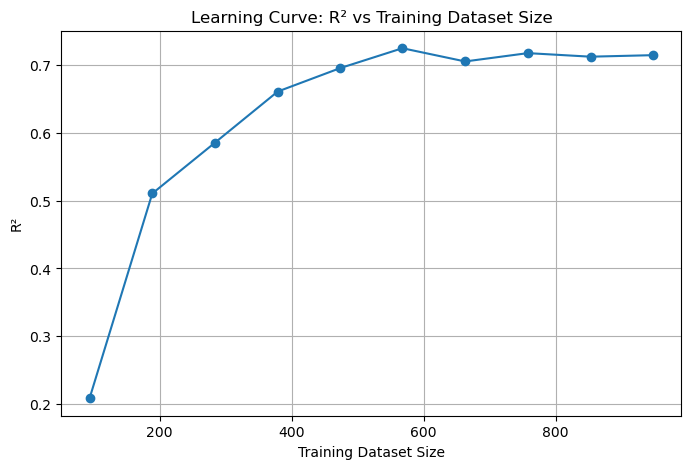

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    r2_scores,
    marker='o'
)

plt.xlabel("Training Dataset Size")
plt.ylabel("R²")
plt.title("Learning Curve: R² vs Training Dataset Size")

plt.grid(True)

plt.savefig(
    "LearningCurve_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

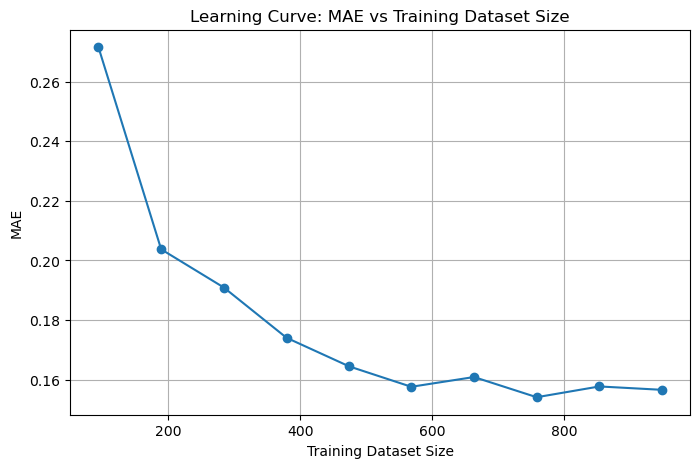

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    mae_scores,
    marker='o'
)

plt.xlabel("Training Dataset Size")
plt.ylabel("MAE")
plt.title("Learning Curve: MAE vs Training Dataset Size")

plt.grid(True)

plt.savefig(
    "LearningCurve_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

* As when we are getting the R2 and MAE values as constant with increasing the number of the data points.
* Then  we have reached the performance limit of your current feature set and model.

# Final Model 

In [64]:
print(type(model_50))

<class 'xgboost.sklearn.XGBRegressor'>


In [65]:
# Final model
import pickle

with open("final_xgb_top50.pkl","wb") as f:
    pickle.dump(model_50,f)

In [66]:
import os

print(os.path.getsize("final_xgb_top50.pkl"))

505090
